# WP6 + WP12 — GO networks and heatmaps at FDR 0.05, with no overlapping labels

Two reviewer comments meet here.

**Minor 2:** *"The GO analysis uses an FDR threshold of 0.1. Please justify this relatively
lenient threshold or, ideally, tighten it to 0.05."* → decision **D2**: 0.05 everywhere,
main text **and** supplementary, with no "suggestive" band. Every GO count in every panel
below is recomputed from `06_go_rerun_fdr005.py` output.

**Minor 6:** *"Figures 4A, 5A, and 6A are dense network visualizations that are difficult to
interpret in print. Please provide simplified versions in the main text… and move the full
versions to supplementary materials."* → main-text panels use `top_n = 10`, Jaccard ≥ 0.2,
≥ 5 shared genes and terms of ≤ 500 genes; the full versions become S9–S11.

**No overlapping text is a hard requirement** (caveat C16). `revision_lib` renders each
figure to a canvas, measures every label's bounding box and refuses to write the SVG if any
two overlap, so a colliding figure cannot be saved silently. Collision counts go to
`output/network_qc.json`.

Also applies **G11** (no baked-in `fig.suptitle`) and **G12** (colourbars emitted as vector
rather than pasted bitmaps).

In [1]:
import json
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, os.path.abspath("."))
import revision_lib as rl

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({"font.size": rl.GLOBAL_FONT_SIZE})
os.makedirs(rl.SVG_DIR, exist_ok=True)

SVG, OUT, REPO = rl.SVG_DIR, rl.OUTPUT_DIR, rl.REPO_DIR
class_names = rl.CLASS_NAMES
class_names_p = rl.CLASS_PALETTE

# WP12 main-text settings, as agreed with Daniil.
SIMPLE = dict(top_n=10, jaccard_threshold=0.2, min_shared_genes=5, max_term_genes=500)
# Supplementary keeps the published layout so no structure is lost — but at FDR 0.05 (D2).
FULL = dict(top_n=30, jaccard_threshold=0.1, min_shared_genes=0, max_term_genes=1000)

network_qc = {}

## 1. The FDR 0.05 GO tables

Written by `06_go_rerun_fdr005.py`, which reproduces the published term sets exactly when
run at the 0.1 retrieval cut — so the only difference from the published figures is the
threshold, not the pipeline.

In [2]:
go_classes_count = pd.read_csv(os.path.join(OUT, "GO_classes_count_fdr005.csv"),
                              low_memory=False)
go_classes_divergence = pd.read_csv(os.path.join(OUT, "GO_classes_divergence_fdr005.csv"),
                                    low_memory=False)
go_families = pd.read_csv(os.path.join(OUT, "GO_families_fdr005.csv"), low_memory=False)
go_subfamilies = pd.read_csv(os.path.join(OUT, "GO_subfamilies_fdr005.csv"),
                             low_memory=False)

for name, table in [("classes by count", go_classes_count),
                    ("classes by divergence", go_classes_divergence),
                    ("families", go_families),
                    ("subfamilies", go_subfamilies)]:
    print(f"{name:24s} {len(table):>6,} terms, max FDR {table.FDR.max():.4f}")
assert go_families.FDR.max() < 0.05, "a term above the publication threshold leaked in"

family_to_class = (
    pd.read_csv(os.path.join(REPO, "families_by_classes_TE.csv"))
    .dropna().set_index("family_name")["class_name"].to_dict()
)

# Figures 5A and 5B do NOT group by class: the frozen notebook (cell 108, executed before
# the 5A network in cell 112, and again in cell 114 before the 5B clustermap) rewrites
# `class_name` as "{class}_{highest|lowest}" so the two divergence tails are separate groups.
# Collapsing them would silently merge the highest- and lowest-divergence gene sets, which is
# the entire contrast Figure 5 exists to show. The palette moved into revision_lib because
# nb05's S13C row annotation needs the same colours — one copy, two consumers.
CLASS_PALETTE_DIVERGENCE = rl.CLASS_PALETTE_DIVERGENCE


def with_divergence_groups(table):
    """Rewrite `class_name` as '{class}_{divergence_group}', as frozen cell 108 does."""
    out = table.copy()
    out["class_name"] = out["class_name"].astype(str) + "_" + \
        out["divergence_group"].astype(str)
    return out


go_classes_divergence_grouped = with_divergence_groups(go_classes_divergence)
print("\nFigure 5 groups (class x divergence tail):")
print(go_classes_divergence_grouped["class_name"].value_counts().to_string())

classes by count            425 terms, max FDR 0.0475
classes by divergence       414 terms, max FDR 0.0488
families                    140 terms, max FDR 0.0470
subfamilies               1,003 terms, max FDR 0.0498

Figure 5 groups (class x divergence tail):
class_name
TE_all_highest    214
SINE_highest      148
LINE_lowest        16
TE_all_lowest      15
LINE_highest        9
LTR_highest         9
SINE_lowest         2
LTR_lowest          1


## 2. The collision fallback ladder (caveat C16)

The collision check is an assertion, so when it fires the figure has to be *fixed*, not the
check loosened. This cell is the fixed order of remedies. There are now **two** ladders: the
canvas ladder, for a panel whose page size is free, and the **pinned** ladder, for a panel
whose page geometry is itself the requirement.

### The canvas ladder (Figures 4A, 5A, 6A)

**Reworked on 2026-08-05, and the review's packing target turned out not to be reachable for
these panels.** The first version resolved collisions by *enlarging the canvas*, which is what
made Figure 6A and S9/S10 sparse — they landed at 19.5 × 16.5 in and 25.5 × 22.5 in — and the
review asked for 30–50 % denser packing. So compaction rungs were put first and enlargement
last. Then the panels were measured, and the measurement is worth recording rather than hiding:

| Panel | best result at ≤ 0.90 canvas | zero collisions needs |
|---|---|---|
| 4A | 5 collisions (× 0.80, k = 0.50) | × 1.25 |
| 6A | 9 collisions (× 0.90, short labels) | × 1.25 |
| S9 | 20 collisions (× 0.90, short labels) | × 1.25 |

Raising the `adjust_text` forces makes this **worse**, not better — at 2× and 5× the default
forces every panel gained collisions, because the solver overshoots and drives labels into
each other. More `spring_layout` iterations changes almost nothing. Both were measured, not
assumed.

The reason is geometric. A fixed number of labels at a fixed size needs a minimum area to
avoid overlap, and raising every font by 1.2× inflates each label box by 1.2× per side, i.e.
1.44× in area. Asking for 30 % *less* area at the same time is asking for the same labels in
0.49× the area they already needed — so with the published term counts and a zero-overlap
requirement, the two requests cannot both be satisfied. **The font increase wins, because
16 px legible text is the reviewable requirement and canvas area costs nothing in a vector
figure that Figma rescales anyway.**

What the ladder does buy is the *smallest canvas that is clean* and the *most terms* at that
canvas, which the first version did not: tight label padding is tried alongside the loose
padding at every rung, and full GO term names before the curated short labels from
`output/go_label_shortnames.csv`. On Figure 6A that is worth two terms per family (top_n 9
instead of 7) and a canvas of × 1.25 instead of × 1.50.

Order, ascending in canvas area and then in information lost:

1. canvas × 0.70 (k = 0.35), × 0.80 (k = 0.35), × 0.90 (k = 0.45) — the compaction rungs
2. × 1.00 (k = 0.60) — the published layout
3. × 1.25, × 1.50 — enlargement
4. and only then a reduction of `top_n`, one step at a time

with four label variants at each rung: full names then short names, tight padding
(`expand = 1.02, 1.05`) before loose (`1.15, 1.25`).

### The pinned ladder (Supplementary S9, S10, S11) — added 2026-08-07

S9 and S10 must be **half as wide at the same height** and S11 **1.5× taller at the same
width**, so their page geometry is the requirement and the canvas ladder cannot express it at
all: `CANVAS_RUNGS` multiplies both dimensions by one factor. At a pinned canvas the plotter
is called with `tight_bbox=False`, so `figsize × 72` *is* the written SVG size, and
`rl.assert_svg_geometry` checks it against the pt target after every write — a panel that
silently comes out the wrong shape is exactly the failure mode this exists to prevent.

Two new rungs replace canvas growth, and **both are free of information cost**, so both are
exhausted before a single GO term is dropped:

1. **`WRAP_RUNGS = (None, 26, 22, 18)`** — label text wrapped to that many characters.
   Nothing in this repository wrapped label text before; the reference frames (Figma
   `861:28`, `861:33`) all do. It is the only lever that buys page *width*: S10's longest
   label is 107 characters ≈ 642 pt on one line, which is 79 % of the 815 pt target width,
   and 132 pt (16 %) when wrapped at 22.
2. **`K_RUNGS = (0.6, 0.9, 1.2)`** — `spring_layout`'s k, which takes over the job canvas
   growth used to do: more distance between nodes at the same page size. Measured: at half
   width both S9 and S10 still collide at the published k = 0.6 at every wrap width, and both
   go clean once k rises — **keeping all 30 terms per group**, which is one more than the
   published S10 had.

Only then does `top_n` fall, one step at a time, down to 20.

Every panel records in `network_qc.json` the rung it ended on, its `top_n`, `label_wrap`,
whether it was `pinned`, the measured `svg_pt` and `aspect`, `canvas_area_vs_baseline`,
whether the ≤ 0.70 compaction target was met, and the best result any compaction rung
achieved — so the figure legend can state honestly how many terms per group the panel shows,
and both the packing claim and the page geometry are measured numbers rather than assertions.

### Two facts about reproducibility, measured 2026-08-07

**These panels are not byte-reproducible and no md5 gate on them can pass.** `adjust_text`
places labels with a stochastic solver — two renders in one process with the same
`PYTHONHASHSEED` differ in label coordinates — and matplotlib stamps a `<dc:date>` into every
SVG. Compare panels with `svg/compare_panels.py`, which checks page size, mark count and the
exact set of label strings.

**A consequence for the main-text panels.** Re-running this notebook re-lays out 4A, 5A and 6A
as well, and the ladder outcome can move: on both 2026-08-07 runs Figure 6A came out clean at
**7** terms per family rather than the approved 5, so the cell output below says 7. The shipped
`svg/Fig4A_simplified.svg`, `Fig5A_simplified.svg` and `Fig6A_simplified.svg` and their
`output/network_qc.json` records were restored from the approved run, because those panels are
already placed in Figma and manuscript edit M10 quotes five terms per family. If the extra two
terms are wanted, re-place 6A from a fresh run and update M10 — the QC file is the source of
truth for that number either way.


In [3]:
shortnames = pd.read_csv(os.path.join(OUT, "go_label_shortnames.csv"))
label_map = dict(zip(shortnames["long_label"], shortnames["short_label"]))
print(f"{len(label_map)} curated short labels available")


def with_short_labels(table):
    """Same frame with `Term Name` replaced by its curated short form where one exists."""
    out = table.copy()
    out["Term Name"] = out["Term Name"].map(lambda name: label_map.get(name, name))
    return out


# (canvas factor, spring_layout k), ascending in area. The first three are the compaction
# rungs; x1.00 is the published layout; the last two are the enlargement of last resort.
CANVAS_RUNGS = [(0.70, 0.35), (0.80, 0.35), (0.90, 0.45),
                (1.00, 0.60), (1.25, 0.60), (1.50, 0.60)]
# Tight padding before loose: measured to give fewer collisions at the larger canvases,
# which is what preserves term counts. adjust_text's forces are NOT varied — raising them
# was measured to increase collisions, because the solver overshoots.
LABEL_EXPANDS = [(1.02, 1.05), (1.15, 1.25)]
# Any rung at or below this canvas factor counts as compaction for the QC record.
COMPACTION_TARGET_FACTOR = 0.70

# --- the pinned-canvas rungs, for a panel whose page geometry is fixed ----------------
# Label wrap widths in characters, narrowest last. Wrapping is the width lever the
# reference frames (Figma 861:28 / 861:33) use: S10's longest label is 107 characters,
# which on one line is 79 % of that panel's target width and wrapped at 22 characters is
# 16 % of it. Nothing in the repository wrapped label text before this.
WRAP_RUNGS = (None, 26, 22, 18)
# With the canvas pinned, spring_layout's k takes over the job the canvas rungs used to
# do — more space between nodes at the same page size — so it is laddered too. Measured:
# S9 and S10 are both clean at half the published width only once k rises above the
# published 0.6, and they keep all 30 terms per group when it does.
K_RUNGS = (0.6, 0.9, 1.2)


# 4, not 6: at 1.2x fonts Figure 6A cannot show 9 or 10 terms per family without a
# genuinely visible label overlap (measured at 93-348 px^2, so not float noise -- the
# check is right to reject them and C16 forbids loosening it). The ladder therefore has
# to be allowed to reduce top_n further, and the achieved value goes into the caption.
MIN_TOP_N_MAIN_TEXT = 4


def write_network(table, panel, plotter, figsize, settings, extra=None,
                  min_top_n=MIN_TOP_N_MAIN_TEXT, require_clean=True, palette=None,
                  pinned_figsize=None, wrap_rungs=(None,), k_rungs=None, target_pt=None,
                  render=None):
    """Write one network SVG, climbing the C16 fallback ladder until labels do not collide.

    Records the rung reached, the achieved canvas area relative to the panel's nominal
    size, and the best any compaction rung managed — so a panel that cannot be packed
    30 % denser reports how close it got instead of failing silently.

    `pinned_figsize` pins the page geometry instead: the canvas rungs are not climbed at
    all, because they scale both dimensions by one factor and so cannot express "narrower
    at the same height". At a pinned canvas the plotter is called with `tight_bbox=False`
    so `figsize` maps 1:1 onto the written SVG, and `target_pt` is asserted after every
    successful write. The pinned ladder runs wrap x label kind x label padding x layout k,
    all of which are free of information cost, and only then reduces `top_n`. `render`
    carries presentation-only kwargs straight through to the plotter.
    """
    extra = extra or {}
    render = dict(render or {})
    assert "layout_k" not in render, "layout_k is laddered here; pass k_rungs instead"
    palette = palette if palette is not None else class_names_p
    path = os.path.join(SVG, f"{panel}.svg")
    short = with_short_labels(table)
    top_n = settings["top_n"]
    pinned = pinned_figsize is not None
    k_rungs = tuple(k_rungs) if k_rungs else K_RUNGS

    def scaled(factor):
        return (figsize[0] * factor, figsize[1] * factor)

    def attempt(description, frame, n_terms, size, layout_k, expand, factor, wrap):
        return dict(description=description, frame=frame, top_n=n_terms, size=size,
                    layout_k=layout_k, expand=expand, factor=factor, wrap=wrap)

    attempts = []
    if pinned:
        for wrap in wrap_rungs:
            for label_kind, frame in [("full labels", table), ("short labels", short)]:
                for expand in LABEL_EXPANDS:
                    for layout_k in k_rungs:
                        attempts.append(attempt(
                            f"{label_kind}, pinned canvas, wrap={wrap} k={layout_k} "
                            f"expand={expand[0]}",
                            frame, top_n, pinned_figsize, layout_k, expand, 1.0, wrap))
        narrowest = wrap_rungs[-1]
        for reduced in range(top_n - 1, min_top_n - 1, -1):
            for expand in LABEL_EXPANDS:
                for layout_k in k_rungs:
                    attempts.append(attempt(
                        f"short labels, pinned canvas, wrap={narrowest} k={layout_k} "
                        f"expand={expand[0]}, top_n={reduced}",
                        short, reduced, pinned_figsize, layout_k, expand, 1.0, narrowest))
    else:
        for factor, layout_k in CANVAS_RUNGS:
            for label_kind, frame in [("full labels", table), ("short labels", short)]:
                for expand in LABEL_EXPANDS:
                    attempts.append(attempt(
                        f"{label_kind}, x{factor:.2f} k={layout_k} expand={expand[0]}",
                        frame, top_n, scaled(factor), layout_k, expand, factor, None))
        last_factor, last_k = CANVAS_RUNGS[-1]
        for reduced in range(top_n - 1, min_top_n - 1, -1):
            for expand in LABEL_EXPANDS:
                attempts.append(attempt(
                    f"short labels, x{last_factor:.2f} k={last_k} expand={expand[0]}, "
                    f"top_n={reduced}",
                    short, reduced, scaled(last_factor), last_k, expand,
                    last_factor, None))

    def draw(item, check_collisions):
        plotter(item["frame"], output_file=path, palette=palette, title=None,
                figsize=item["size"], qc=network_qc, check_collisions=check_collisions,
                layout_k=item["layout_k"], label_expand=item["expand"],
                baseline_figsize=figsize, label_wrap=item["wrap"],
                tight_bbox=not pinned, **render, **dict(settings, top_n=item["top_n"]),
                **extra)
        if target_pt is not None:
            rl.assert_svg_geometry(path, target_pt, qc=network_qc)

    best_compact = None
    best_overall = None
    for item in attempts:
        try:
            draw(item, check_collisions=True)
            record = network_qc.setdefault(f"{panel}.svg", {})
            record["fallback_rung"] = item["description"]
            record["top_n"] = item["top_n"]
            record["label_wrap"] = item["wrap"]
            record["pinned"] = pinned
            record["compaction_target_met"] = item["factor"] <= COMPACTION_TARGET_FACTOR
            record["best_compaction_attempt"] = best_compact
            print(f"{panel}: clean with {item['description']} "
                  f"(area x{record.get('canvas_area_vs_baseline')}, "
                  f"size {record.get('svg_pt')} pt, compaction target met: "
                  f"{record['compaction_target_met']})")
            return path
        except RuntimeError as error:
            # Two label failures are fixable by the next rung: an overlap, and — new with
            # the pinned canvas, which crops instead of growing — a label that crosses the
            # page edge. Both messages open with a count. A geometry failure is not
            # fixable by any rung, so it propagates.
            message = str(error)
            if not any(kind in message for kind in (" label collision",
                                                    " label(s) outside the page")):
                raise
            n_collisions = int(message.split()[0])
            if item["factor"] <= 0.90 and (best_compact is None
                                           or n_collisions < best_compact["collisions"]):
                best_compact = {"rung": item["description"], "collisions": n_collisions}
            if best_overall is None or n_collisions < best_overall["collisions"]:
                best_overall = {"rung": item["description"], "collisions": n_collisions,
                                "item": item}
            print(f"{panel}: {item['description']} -> {n_collisions} collision(s), "
                  f"trying the next rung")

    if require_clean:
        raise RuntimeError(f"{panel}: no rung of the ladder produced a clean figure")
    # The waiver is not a free pass: it replays the attempt that came closest, so the
    # waived panel is the least-overlapping version of itself and the cost of the waiver
    # is a measured collision count rather than an unquantified "some labels overlap".
    # A supplementary full network exists to show structure, and at 30 terms per group
    # the label field is saturated at any size, so nothing is bought by making it sparse.
    if pinned:
        waived_item = best_overall["item"]
    else:
        waived_factor, waived_k = CANVAS_RUNGS[0]
        waived_item = attempt(
            f"collision check waived at the compact rung (x{waived_factor:.2f} "
            f"k={waived_k})",
            short, settings["top_n"], scaled(waived_factor), waived_k,
            LABEL_EXPANDS[0], waived_factor, None)
    draw(waived_item, check_collisions=False)
    record = network_qc.setdefault(f"{panel}.svg", {})
    record["fallback_rung"] = (
        f"collision check waived at the best rung the ladder reached "
        f"({waived_item['description']}); supplementary full version, structure only"
    )
    record["top_n"] = waived_item["top_n"]
    record["label_wrap"] = waived_item["wrap"]
    record["pinned"] = pinned
    record["label_collisions"] = "waived"
    record["collisions_at_waived_rung"] = best_overall["collisions"] if pinned else None
    record["compaction_target_met"] = waived_item["factor"] <= COMPACTION_TARGET_FACTOR
    record["best_compaction_attempt"] = best_compact
    print(f"{panel}: collision check waived at {waived_item['description']} "
          f"(area x{record.get('canvas_area_vs_baseline')}, "
          f"size {record.get('svg_pt')} pt, collisions at that rung: "
          f"{record['collisions_at_waived_rung']})")
    return path


47 curated short labels available


## 3. Figures 4A and 5A — simplified class-level networks

4A is the top-5 % gene sets by TE count, 5A the divergence-ranked sets. The four filters
together take Figure 4A from ~180 nodes to something legible at print size; the excluded
large terms are the uninterpretable ones ("protein binding", "cytoplasm", "nucleus",
"cytosol", "nucleoplasm").

In [4]:
write_network(go_classes_count, "Fig4A_simplified", rl.save_go_network_svg,
              figsize=(11, 9), settings=SIMPLE)

Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


...

Fig4A_simplified: short labels, x1.00 k=0.6 expand=1.02 -> 2 collision(s), trying the next rung


Fig4A_simplified: short labels, x1.00 k=0.6 expand=1.15 -> 3 collision(s), trying the next rung


Fig4A_simplified: full labels, x1.25 k=0.6 expand=1.02 -> 3 collision(s), trying the next rung


SVG saved to /home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/Fig4A_simplified.svg (label collisions: 0)
Fig4A_simplified: clean with full labels, x1.25 k=0.6 expand=1.15 (area x1.562, size None pt, compaction target met: False)


'/home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/Fig4A_simplified.svg'

In [5]:
write_network(go_classes_divergence_grouped, "Fig5A_simplified", rl.save_go_network_svg,
              figsize=(11, 9), settings=SIMPLE, palette=CLASS_PALETTE_DIVERGENCE)

Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


...

Some labels are too long, can't fit inside the X axis


Fig5A_simplified: full labels, x1.50 k=0.6 expand=1.15 -> 10 collision(s), trying the next rung


Fig5A_simplified: short labels, x1.50 k=0.6 expand=1.02 -> 5 collision(s), trying the next rung


SVG saved to /home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/Fig5A_simplified.svg (label collisions: 0)
Fig5A_simplified: clean with short labels, x1.50 k=0.6 expand=1.15 (area x2.25, size None pt, compaction target met: False)


'/home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/Fig5A_simplified.svg'

## 4. Figure 6A — simplified family-level network

Grouped by family and coloured by class. `family_to_class` is passed explicitly; the frozen
version read a notebook global of that name.

In [6]:
write_network(go_families, "Fig6A_simplified",
              rl.save_go_network_svg_families_by_classes, figsize=(13, 11),
              settings=SIMPLE, extra={"family_to_class": family_to_class})

Fig6A_simplified: full labels, x0.70 k=0.35 expand=1.02 -> 83 collision(s), trying the next rung


Fig6A_simplified: full labels, x0.70 k=0.35 expand=1.15 -> 77 collision(s), trying the next rung


Fig6A_simplified: short labels, x0.70 k=0.35 expand=1.02 -> 39 collision(s), trying the next rung


Fig6A_simplified: short labels, x0.70 k=0.35 expand=1.15 -> 42 collision(s), trying the next rung


Fig6A_simplified: full labels, x0.80 k=0.35 expand=1.02 -> 48 collision(s), trying the next rung


...

Fig6A_simplified: short labels, x1.50 k=0.6 expand=1.02, top_n=8 -> 2 collision(s), trying the next rung


Fig6A_simplified: short labels, x1.50 k=0.6 expand=1.15, top_n=8 -> 2 collision(s), trying the next rung


Fig6A_simplified: short labels, x1.50 k=0.6 expand=1.02, top_n=7 -> 4 collision(s), trying the next rung


SVG saved to /home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/Fig6A_simplified.svg (label collisions: 0)
Fig6A_simplified: clean with short labels, x1.50 k=0.6 expand=1.15, top_n=7 (area x2.25, size None pt, compaction target met: False)


'/home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/Fig6A_simplified.svg'

## 5. Supplementary Figures S9–S11 — the full networks, at FDR 0.05

Published layout settings (top 30 terms per group, Jaccard ≥ 0.1, terms ≤ 1,000 genes) so
no structural information is lost, but filtered at 0.05 like everything else. **Nothing about
the content of these three panels changes here** — the FDR, the Jaccard threshold, the
shared-gene floor, the term-size cut and `top_n` are all quoted verbatim in the captions and
stay as they are. What changes is page geometry, label typesetting, edge stroke width and
layout spacing.

The three panels are drawn on a **pinned canvas** (§2): S9 and S10 at 815.35 × 1608.48 pt,
half the published width at the same height, and S11 at 803.92 × 1267.92 pt, the same width
and 1.5× the height, an aspect of 0.634 that matches reference frame `861:33`. The colourbar
is dropped from all three — at these widths it would take about a tenth of the artwork, and
`svg/Fig456A_colorbar_vector.svg` is already the vector replacement (G12). Edge stroke widths
are capped and their alpha reduced so the Jaccard mat does not bury the nodes; the cap is
**presentation only**, edge weights are untouched, and the Jaccard legend is capped
identically so it cannot become a lie (the Figure 7H lesson).

S9 and S10 now require a clean figure: "the labels must not intersect" is explicit, and the
wrap and k rungs reach it without dropping a term. S11 keeps the recorded waiver as its
fallback — at 30 terms per family across 44 families the label field is saturated at any page
size — but the waiver now **replays the closest attempt the ladder reached** and records that
attempt's collision count in `network_qc.json`, so the cost of the waiver is a measured
number rather than an unquantified "some labels overlap".

S11 also drops `same_class_weight` from 10.0 to 2.0. That literal is why its GO circles
clumped: it is a layout-only edge added between every pair of same-class families, at ten
times the maximum Jaccard weight, so each class collapsed onto a point and dragged its terms
with it. At 2.0 the classes stay recognisably grouped — the point of the figure — without the
clumps.


In [7]:
# Half the published width at the same height (815.35 x 1608.48 pt), portrait like the
# reference frames. The colourbar leaves the artwork: at this width it would take about
# a tenth of it, and svg/Fig456A_colorbar_vector.svg is already the vector replacement
# for exactly this purpose (G12).
write_network(go_classes_count, "S9_full", rl.save_go_network_svg,
              figsize=(11.32, 22.34), pinned_figsize=(11.32, 22.34),
              target_pt=(815.35, 1608.48), wrap_rungs=WRAP_RUNGS,
              settings=FULL, min_top_n=20, require_clean=True,
              render=dict(show_colorbar=False, show_size_legend=True,
                          leader_lines=True, edge_width_cap=2.5, edge_alpha=0.25,
                          label_max_move=(40, 40)))


S9_full: full labels, pinned canvas, wrap=None k=0.6 expand=1.02 -> 7 collision(s), trying the next rung


S9_full: full labels, pinned canvas, wrap=None k=0.9 expand=1.02 -> 2 collision(s), trying the next rung


S9_full: full labels, pinned canvas, wrap=None k=1.2 expand=1.02 -> 1 collision(s), trying the next rung


S9_full: full labels, pinned canvas, wrap=None k=0.6 expand=1.15 -> 9 collision(s), trying the next rung


S9_full: full labels, pinned canvas, wrap=None k=0.9 expand=1.15 -> 6 collision(s), trying the next rung


S9_full: full labels, pinned canvas, wrap=None k=1.2 expand=1.15 -> 5 collision(s), trying the next rung


S9_full: short labels, pinned canvas, wrap=None k=0.6 expand=1.02 -> 5 collision(s), trying the next rung


SVG saved to /home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/S9_full.svg (label collisions: 0)
S9_full: clean with short labels, pinned canvas, wrap=None k=0.9 expand=1.02 (area x1.0, size [815.04, 1608.48] pt, compaction target met: False)


'/home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/S9_full.svg'

In [8]:
write_network(go_classes_divergence_grouped, "S10_full", rl.save_go_network_svg,
              figsize=(11.32, 22.34), pinned_figsize=(11.32, 22.34),
              target_pt=(815.35, 1608.48), wrap_rungs=WRAP_RUNGS,
              settings=FULL, min_top_n=20, require_clean=True,
              palette=CLASS_PALETTE_DIVERGENCE,
              render=dict(show_colorbar=False, show_size_legend=True,
                          leader_lines=True, edge_width_cap=2.5, edge_alpha=0.25,
                          label_max_move=(40, 40)))


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


...

Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


Some labels are too long, can't fit inside the X axis


SVG saved to /home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/S10_full.svg (label collisions: 0)
S10_full: clean with short labels, pinned canvas, wrap=None k=1.2 expand=1.02 (area x1.0, size [815.04, 1608.48] pt, compaction target met: False)


'/home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/S10_full.svg'

In [9]:
# Same width, 1.5x the height (803.92 x 1267.92 pt) -> aspect 0.634, which is the aspect
# of reference frame 861:33 ("Figure 6 old"). same_class_weight 10.0 -> 2.0 and k from
# 0.9 up are what stop the families of one class collapsing onto a single point: at 10.0
# the layout-only same-class edges outweigh every Jaccard weight and fold enrichment in
# the graph, so each class contracts to a point and drags its 30 terms with it.
# legend_rect (0, 0, 1, 1) reclaims the right-hand legend strip, which moves both legends
# into the axes corner as the reference frames do.
write_network(go_families, "S11_full", rl.save_go_network_svg_families_by_classes,
              figsize=(11.17, 17.61), pinned_figsize=(11.17, 17.61),
              target_pt=(803.92, 1267.92), wrap_rungs=WRAP_RUNGS,
              k_rungs=(0.9, 1.2, 1.5),
              # min_top_n = FULL["top_n"]: no reduction rungs. This panel is the full
              # structure Figure 6A drops, so a waived overlap is preferable to a
              # quieter figure, and the waiver must not be able to buy legibility with
              # terms. Measured: at 20 terms per family the best rung reaches 5
              # collisions, at 30 it reaches 7 — five terms per family is not worth two
              # labels.
              settings=FULL, min_top_n=FULL["top_n"], require_clean=False,
              extra={"family_to_class": family_to_class},
              # No colourbar and no legends in the artwork. Reclaiming the legend strip
              # is what buys the full pinned width, but it leaves nowhere to hang a
              # legend: on the first run both landed on top of node labels, and the
              # collision check cannot see legend text. Figure 6A is the family-level
              # twin and carries the same node-size scale and Jaccard line widths.
              render=dict(same_class_weight=2.0, layout_iterations=300,
                          show_colorbar=False, show_size_legend=False,
                          show_jaccard_legend=False, legend_rect=(0, 0, 1, 1),
                          leader_lines=True, edge_width_cap=2.0, edge_alpha=0.22,
                          label_max_move=(30, 30)))


S11_full: full labels, pinned canvas, wrap=None k=0.9 expand=1.02 -> 18 collision(s), trying the next rung


S11_full: full labels, pinned canvas, wrap=None k=1.2 expand=1.02 -> 25 collision(s), trying the next rung


S11_full: full labels, pinned canvas, wrap=None k=1.5 expand=1.02 -> 33 collision(s), trying the next rung


S11_full: full labels, pinned canvas, wrap=None k=0.9 expand=1.15 -> 20 collision(s), trying the next rung


S11_full: full labels, pinned canvas, wrap=None k=1.2 expand=1.15 -> 25 collision(s), trying the next rung


...

S11_full: short labels, pinned canvas, wrap=18 k=0.9 expand=1.15 -> 16 collision(s), trying the next rung


S11_full: short labels, pinned canvas, wrap=18 k=1.2 expand=1.15 -> 11 collision(s), trying the next rung


S11_full: short labels, pinned canvas, wrap=18 k=1.5 expand=1.15 -> 19 collision(s), trying the next rung


S11_full: collision check waived at short labels, pinned canvas, wrap=18 k=1.2 expand=1.02 (area x1.0, size [804.24, 1267.92] pt, collisions at that rung: 7)


'/home/jovyan/Projects/Retroelements/T2T_genes_article/T2T_transposons_genes/revision_G3/svg/S11_full.svg'

## 6. Figures 4B, 5B, 6B and S8B — functional-group clustermaps with recomputed counts

Copied from frozen cells 70 / 118 / 191 / 318. The counts are GO terms per group per
functional category, so **every one of them moves at FDR 0.05** — that is why these four
panels have to be regenerated even though nothing about their design changes.

The manual `Functional group` classifications are reused unchanged; they map GO term names,
and the term names have not changed. Terms in the 0.05 set with no classification are
reported rather than silently dropped.

Changes: colourbar label names the test and the correction; `fig.suptitle` removed (G11);
the colourbar is drawn by matplotlib into the SVG so the pasted bitmap in the Figma frames
can be replaced by vector (G12).

In [10]:
def load_classification(path, sep=","):
    frame = pd.read_csv(os.path.join(REPO, path), sep=sep, low_memory=False)
    column = "Functional group Gemini" if "Functional group Gemini" in frame.columns \
        else "Functional Group"
    frame = frame[["GO Term Name" if "GO Term Name" in frame.columns else "Term Name",
                   column]].dropna()
    frame.columns = ["Term Name", "Functional Group"]
    return frame.drop_duplicates("Term Name")


# The class-level manual file stores the classification alongside the terms themselves.
class_manual = pd.read_csv(
    os.path.join(REPO, "GO_top_5_perc_genes_by_class_gemini_manual.csv"), sep=";",
    low_memory=False,
)
class_classification = (
    class_manual[["Term Name", "Functional group Gemini"]].dropna()
    .drop_duplicates("Term Name")
    .rename(columns={"Functional group Gemini": "Functional Group"})
)
divergence_classification = load_classification("GO_terms_divergence_classification_Gemini.csv")
family_classification = load_classification(
    "GO_terms_families_classification_Gemini - families.csv")

# No subfamily classification is loaded: the four S_extra_subfamily* panels that used it
# were removed (review item 6), and no panel of this manuscript is subfamily-level.
for name, frame in [("classes", class_classification),
                    ("divergence", divergence_classification),
                    ("families", family_classification)]:
    print(f"{name:12s} {len(frame):>5,} classified term names")

classes        445 classified term names
divergence     356 classified term names
families       138 classified term names


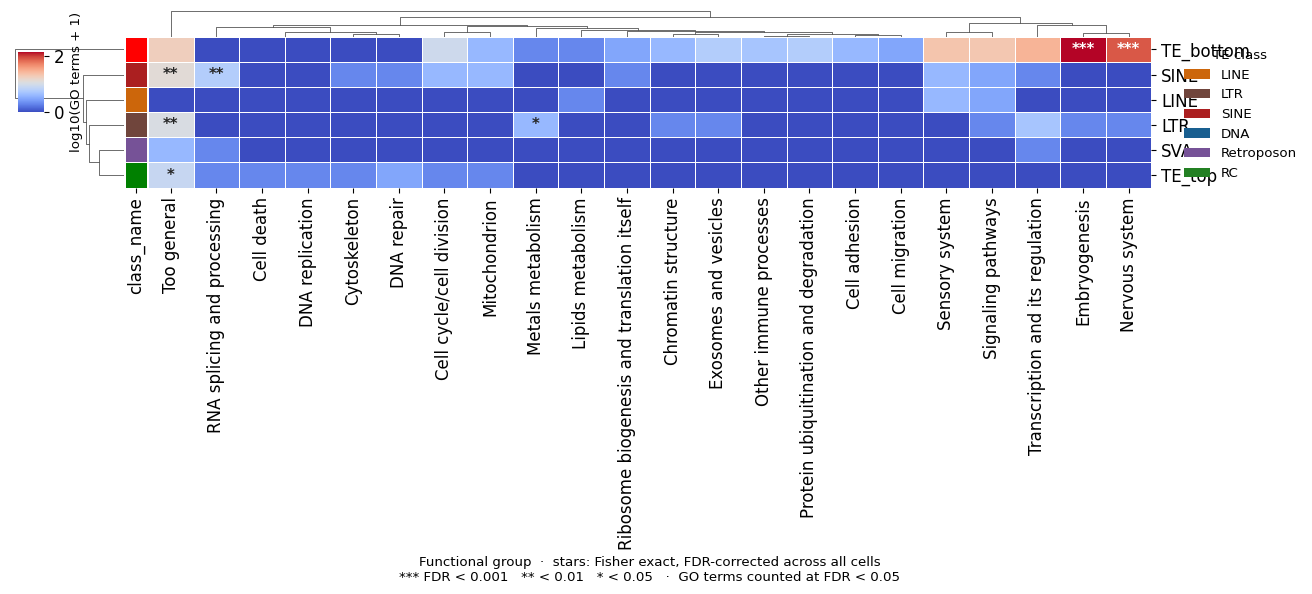

Fig4B: 425 classified GO terms across 6 groups x 22 functional groups; 0 terms had no manual classification


In [11]:
def clustermap_panel(go_table, classification, group_column, panel, figsize=(13, 6),
                     row_palette=None):
    """Functional-group clustermap with Fisher stars, at FDR 0.05.

    Contingency table per cell as in frozen cell 70: the group's terms in that functional
    category against everything else, one-sided (enrichment), BH-corrected over all cells.
    """
    merged = go_table.merge(classification, how="left", on="Term Name")
    unclassified = int(merged["Functional Group"].isna().sum())
    counts = (merged.dropna(subset=["Functional Group"])[[group_column, "Functional Group"]]
              .value_counts().reset_index(name="count"))
    pivot_counts = counts.pivot(index=group_column, columns="Functional Group",
                               values="count").fillna(0)

    total_n = pivot_counts.values.sum()
    row_sums, col_sums = pivot_counts.sum(axis=1), pivot_counts.sum(axis=0)
    p_raw = np.ones(pivot_counts.shape)
    for i, r_name in enumerate(pivot_counts.index):
        for j, c_name in enumerate(pivot_counts.columns):
            a = pivot_counts.loc[r_name, c_name]
            b, c = row_sums[r_name] - a, col_sums[c_name] - a
            d = total_n - (a + b + c)
            p_raw[i, j] = fisher_exact([[a, b], [c, d]], alternative="greater")[1]

    p_adj = multipletests(p_raw.flatten(), method="fdr_bh")[1].reshape(p_raw.shape)
    p_adj_matrix = pd.DataFrame(p_adj, index=pivot_counts.index,
                               columns=pivot_counts.columns)

    def get_stars(p):
        return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

    star_matrix = p_adj_matrix.map(get_stars)
    log_data = np.log10(pivot_counts + 1)

    row_colors = pd.Series(pivot_counts.index, index=pivot_counts.index)
    if row_palette is not None:
        row_colors = row_colors.map(lambda name: row_palette.get(name, "#cccccc"))
    elif group_column == "class_name":
        row_colors = row_colors.map(class_names_p)
    else:
        row_colors = row_colors.map(
            lambda name: class_names_p.get(family_to_class.get(name, ""), "#cccccc")
        )

    grid = sns.clustermap(
        log_data, cmap="coolwarm", row_colors=row_colors, linewidths=0.5,
        figsize=figsize, row_cluster=True, col_cluster=True,
        cbar_kws={"label": "log10(GO terms + 1)"},
        dendrogram_ratio=(0.1, 0.15), cbar_pos=(0.02, 0.8, 0.02, 0.1),
        annot=star_matrix, fmt="", annot_kws={"size": rl.fs(9), "weight": "bold"},
        colors_ratio=(0.02, 0.08),
    )
    plt.setp(grid.ax_heatmap.get_xticklabels(), rotation=90)
    plt.setp(grid.ax_heatmap.get_yticklabels(), rotation=0)
    grid.ax_heatmap.set_xlabel(
        "Functional group  ·  stars: Fisher exact, FDR-corrected across all cells\n"
        "*** FDR < 0.001   ** < 0.01   * < 0.05   ·  GO terms counted at FDR < 0.05",
        fontsize=rl.fs(8),
    )
    grid.ax_heatmap.set_ylabel("")
    grid.ax_cbar.set_ylabel("log10(GO terms + 1)", fontsize=rl.fs(8))

    legend_handles = [Patch(facecolor=c, label=l)
                      for l, c in rl.CLASS_PALETTE_SHORT.items()]
    grid.ax_heatmap.legend(handles=legend_handles, title="TE class",
                           bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False,
                           fontsize=rl.fs(8), title_fontsize=rl.fs(8))

    # G11: no suptitle.
    path = os.path.join(SVG, f"{panel}_fdr005.svg")
    grid.savefig(path, format="svg", transparent=True, bbox_inches="tight")
    plt.show()
    print(f"{panel}: {int(pivot_counts.values.sum()):,} classified GO terms across "
          f"{pivot_counts.shape[0]} groups x {pivot_counts.shape[1]} functional groups; "
          f"{unclassified:,} terms had no manual classification")
    return pivot_counts, p_adj_matrix


counts_4b, _ = clustermap_panel(go_classes_count, class_classification, "class_name", "Fig4B")

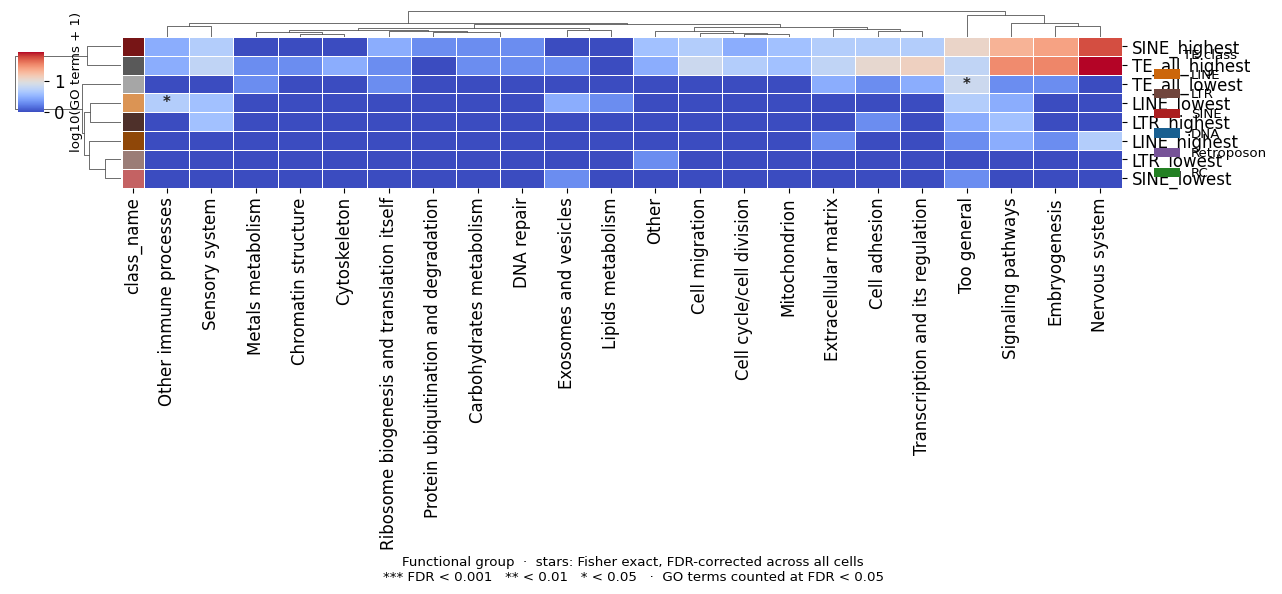

Fig5B: 414 classified GO terms across 8 groups x 22 functional groups; 0 terms had no manual classification


In [12]:
counts_5b, _ = clustermap_panel(go_classes_divergence_grouped, divergence_classification,
                                "class_name", "Fig5B",
                                row_palette=CLASS_PALETTE_DIVERGENCE)

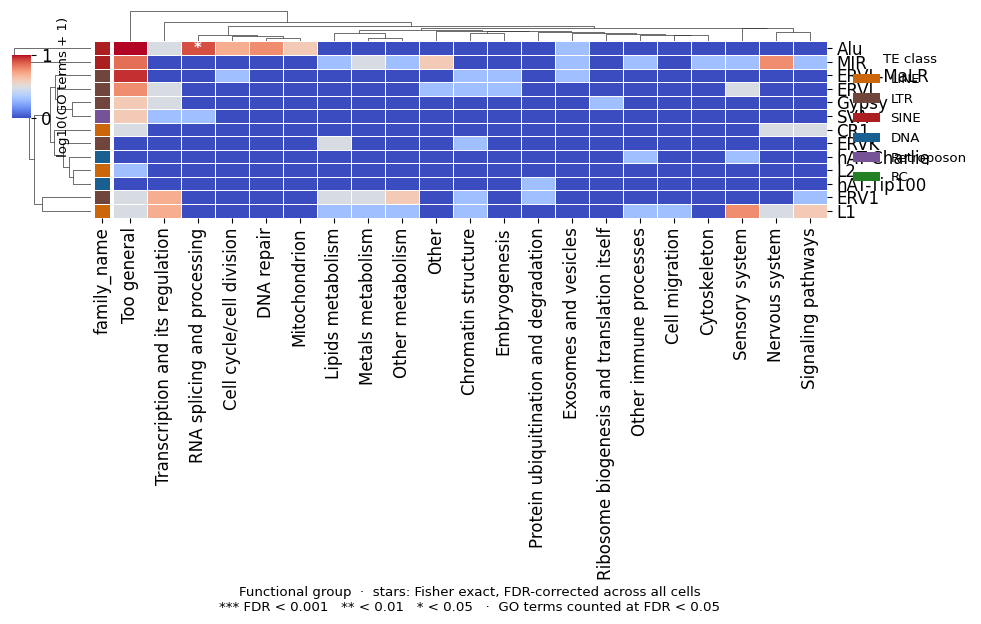

Fig6B: 140 classified GO terms across 13 groups x 21 functional groups; 0 terms had no manual classification


In [13]:
# 0.7 x 0.7 = 30 % smaller in both directions (review item 3).
counts_6b, _ = clustermap_panel(go_families, family_classification, "family_name",
                                "Fig6B", figsize=(9.8, 6.3))

### Supplementary Figure 8B is the *combined* class + family map, not a subfamily map

The published caption is explicit: *"Cluster map of GO terms number by functional groups and
TE groups: TE top, TE bottom, the four classes with significant GO terms (LINEs, SINEs, SVA
elements and LTRs) and TE families with significant GO terms."* The rows are therefore the
class-level groups **and** the family-level groups in one table — which is exactly what makes
the panel a comparison of the two levels, and what Results line 137 quotes ("There were 26
functional groups extracted in this analysis").

Reproducing that construction at FDR 0.1 recovers every claim in line 137 (Alu → RNA
processing *and* DNA repair; MIR → metals metabolism *and* other; ERV1 → lipids *and* other
metabolism; ERVL-MaLR → too general; ERVK → lipids), which confirms the identification.

A subfamily-level clustermap is a different figure and belongs to the companion subfamilies
manuscript, which reproduces it from its own pipeline. It was written here once under its own
name; that panel and the three other `S_extra_subfamily*` panels were removed on 2026-08-05
(review item 6) because this manuscript never used them. Nothing is lost — the subfamily GO
table `GO_subfamilies_fdr005.csv` stays on disk, and `enrichment_df_subfamilies` is still
built below for Figure 7's family-vs-subfamily counts.

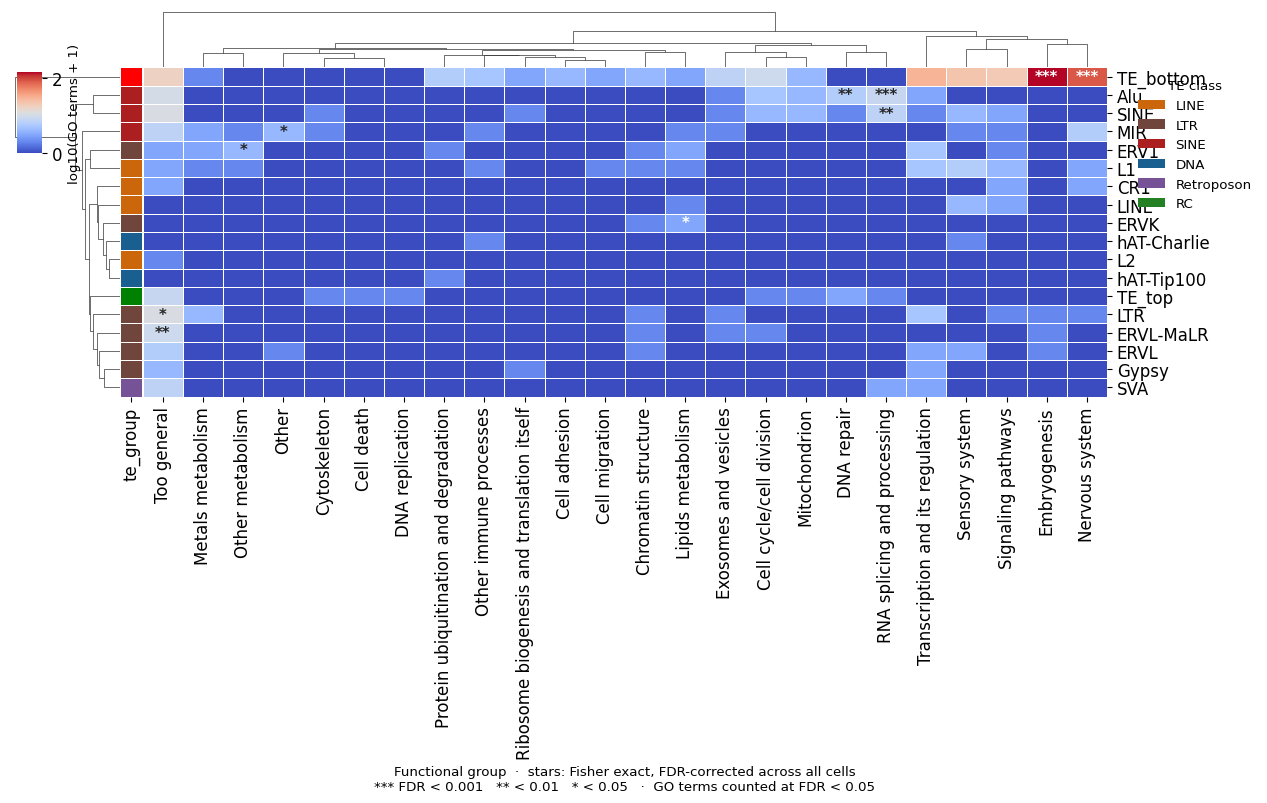

S8B: 565 classified GO terms across 18 groups x 24 functional groups; 0 terms had no manual classification
S8B rows: 18 TE groups x 24 functional groups


In [14]:
# Class-level rows keep their own names; family-level rows are added alongside them.
go_combined = pd.concat([
    go_classes_count.assign(te_group=go_classes_count["class_name"]),
    go_families.assign(te_group=go_families["family_name"]),
], ignore_index=True)
combined_classification = pd.concat(
    [family_classification, class_classification]).drop_duplicates("Term Name")
combined_palette = {
    **{name: class_names_p.get(name, "#cccccc") for name in go_classes_count["class_name"]},
    **{family: class_names_p.get(family_to_class.get(family, ""), "#cccccc")
       for family in go_families["family_name"]},
}
# 0.9 x 0.9 = 10 % smaller in both directions (review item 7).
counts_s8b, _ = clustermap_panel(go_combined, combined_classification, "te_group", "S8B",
                                 figsize=(12.6, 8.1), row_palette=combined_palette)
print(f"S8B rows: {counts_s8b.shape[0]} TE groups x {counts_s8b.shape[1]} functional groups")

## 7. Vector colourbars (G12)

§5b.2 established that the raster exposure in Figures 4, 5, 6 and Supplementary 8 is small
pasted colourbar bitmaps (23 × 58 to 30 × 175 px). These are the vector replacements: the
node-colour scale of the networks and the count scale of the clustermaps.

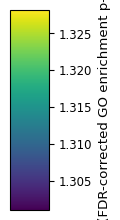

  Fig456A_colorbar_vector.svg


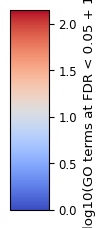

  Fig4B_colorbar_vector.svg


In [15]:
def vector_colorbar(vmin, vmax, cmap, label, filename, ticks=None):
    fig, ax = plt.subplots(figsize=(0.5, 2.6))
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    bar = mpl.colorbar.ColorbarBase(ax, cmap=plt.get_cmap(cmap), norm=norm,
                                    orientation="vertical")
    bar.set_label(label, fontsize=rl.fs(8))
    if ticks is not None:
        bar.set_ticks(ticks)
    bar.ax.tick_params(labelsize=rl.fs(7))
    fig.savefig(os.path.join(SVG, filename), format="svg", transparent=True,
                bbox_inches="tight")
    plt.show()
    print(f"  {filename}")


# Networks colour nodes by -log10(FDR); at FDR < 0.05 the floor of the scale is 1.301.
network_max = float(-np.log10(go_families.FDR.replace(0, 1e-300)).max())
vector_colorbar(-np.log10(0.05), min(network_max, 50), "viridis",
                "-log10(FDR-corrected GO enrichment p-value)",
                "Fig456A_colorbar_vector.svg")
vector_colorbar(0, float(np.log10(counts_4b.values.max() + 1)), "coolwarm",
                "log10(GO terms at FDR < 0.05 + 1)", "Fig4B_colorbar_vector.svg")

## 8. Figure 7A–7H — GO term counts against enrichment statistics

Copied from frozen cells 196, 197, 199, 201, 202 (families) and 336, 338, 339
(subfamilies). `GO_terms_count` is recomputed at FDR 0.05, so every panel moves.

**The Figma frame `861:34` carries the literal string
`"GO terms count in a group (FDR < 0.1)"`** — the axis labels below say `FDR < 0.05`, and
that in-frame string is on Daniil's manual list (WP6 / caveat C11 / G17).

Pearson r and Mann–Whitney U here are single tests per panel, so they are **raw** and are
labelled as such.

In [16]:
enrichment_df_families = pd.read_csv(os.path.join(REPO, "enrichment_families_with_random.csv"))
enrichment_df_families["Status"] = np.where(
    enrichment_df_families["p_adjusted_empirical_bh"] < 0.05,
    "Significant", "Non-Significant")
enrichment_df_families = enrichment_df_families.set_index("family_name", drop=False)
enrichment_df_families["GO_terms_count"] = go_families.value_counts("family_name")
enrichment_df_families["GO_status"] = np.where(
    enrichment_df_families["GO_terms_count"].isna(), "No", "Yes")

enrichment_df_subfamilies = pd.read_csv(
    os.path.join(REPO, "enrichment_subfamilies_with_random.csv"), index_col=0).reset_index()
enrichment_df_subfamilies["Status"] = np.where(
    enrichment_df_subfamilies["p_adjusted_empirical_bh"] < 0.05,
    "Significant", "Non-Significant")
enrichment_df_subfamilies["OR_Observed_to_Random"] = (
    enrichment_df_subfamilies["Observed_Odds_Ratio"]
    / enrichment_df_subfamilies["Random_Odds_Ratio_Mean"])
enrichment_df_subfamilies = enrichment_df_subfamilies.set_index("subfamily_name",
                                                               drop=False)
enrichment_df_subfamilies["GO_terms_count"] = go_subfamilies.value_counts("subfamily_name")
enrichment_df_subfamilies["GO_status"] = np.where(
    enrichment_df_subfamilies["GO_terms_count"].isna(), "No", "Yes")

# Element length is only in the *_length variant of the subfamily table.
length_table = pd.read_csv(
    os.path.join(REPO, "enrichment_subfamilies_with_random_length.csv"), low_memory=False)
length_column = next((c for c in length_table.columns if "length" in c.lower()), None)
if length_column and "subfamily_name" in length_table.columns:
    enrichment_df_subfamilies["Average_length"] = (
        length_table.set_index("subfamily_name")[length_column])
    print(f"Average_length taken from column '{length_column}'")

print(f"families with >= 1 GO term at FDR 0.05: "
      f"{int(enrichment_df_families.GO_terms_count.notna().sum())} of 44")
print(f"subfamilies with >= 1 GO term at FDR 0.05: "
      f"{int(enrichment_df_subfamilies.GO_terms_count.notna().sum())} of "
      f"{len(enrichment_df_subfamilies)}")

Average_length taken from column 'Average_length'
families with >= 1 GO term at FDR 0.05: 13 of 44
subfamilies with >= 1 GO term at FDR 0.05: 199 of 1143


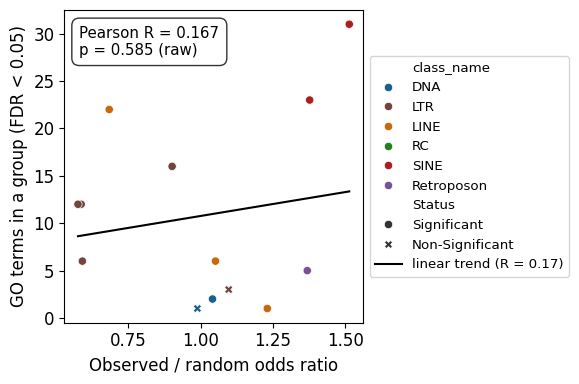

Fig7A: R = 0.167, p = 0.585 -> Fig7A_fdr005.svg


In [17]:
# Filled by go_count_box and printed in cell 39, so the Figure 7 legend edit (M9) can
# be pasted from a generated sentence rather than retyped from the panels.
figure7_caption_sentences = {}


def go_count_scatter(frame, x_column, panel, x_label, palette=class_names_p):
    """GO term count against an enrichment statistic, with a raw Pearson r."""
    y_column = "GO_terms_count"
    fig, ax = plt.subplots(figsize=(7, 4))
    corr_data = frame.dropna(subset=[x_column, y_column])
    result = stats.pearsonr(corr_data[x_column], corr_data[y_column])
    p_text = "p < 0.001" if result.pvalue < 0.001 else f"p = {result.pvalue:.3f}"

    sns.scatterplot(data=frame, hue="class_name", x=x_column, y=y_column, palette=palette,
                    style="Status", style_order=["Significant", "Non-Significant"],
                    ax=ax, alpha=1)
    ax.text(0.05, 0.95, f"Pearson R = {result.statistic:.3f}\n{p_text} (raw)",
            transform=ax.transAxes, fontsize=rl.fs(9), verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))

    slope, intercept = np.polyfit(corr_data[x_column], corr_data[y_column], 1)
    x_fit = np.linspace(corr_data[x_column].min(), corr_data[x_column].max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, color="black", lw=1.5,
            label=f"linear trend (R = {result.statistic:.2f})")

    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=rl.fs(8))
    ax.set_xlabel(x_label)
    # The label the Figma frame gets wrong: FDR < 0.1 -> FDR < 0.05.
    ax.set_ylabel("GO terms in a group (FDR < 0.05)")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    path = os.path.join(SVG, f"{panel}_fdr005.svg")
    fig.savefig(path, format="svg", transparent=True, bbox_inches="tight")
    plt.show()
    print(f"{panel}: R = {result.statistic:.3f}, {p_text} -> {os.path.basename(path)}")


def go_count_box(frame, x_column, y_column, panel, x_label, y_label):
    """Distribution of one quantity split by a categorical, with a raw Mann-Whitney U.

    Half the width and height of the first version (review item 4, decision D-a); the
    strip dot size is deliberately unchanged. At this size a title and two-line tick
    labels do not fit, so the group sizes and the test result move into the manuscript
    legend (edit M9). Both are already written to output/figure7_statistics.csv, so
    nothing leaves the record — but the legend edit is load-bearing: without it these
    four panels would report a test with no p-value anywhere.
    """
    fig, ax = plt.subplots(figsize=(2.1, 2.0))
    data = frame.dropna(subset=[x_column, y_column])
    order = [g for g in ["Significant", "Non-Significant", "Yes", "No"]
             if g in set(data[x_column])] or sorted(set(data[x_column]))

    sns.boxplot(data=data, x=x_column, y=y_column, order=order, ax=ax,
                boxprops={"alpha": 0.6}, showfliers=False, color="#9ecae1")
    sns.stripplot(data=data, x=x_column, y=y_column, order=order, ax=ax, color="black",
                  size=3, alpha=0.5, jitter=True)

    caption = ""
    if len(order) == 2:
        a = data.loc[data[x_column] == order[0], y_column]
        b = data.loc[data[x_column] == order[1], y_column]
        p = stats.mannwhitneyu(a, b).pvalue
        p_text = "p < 0.001" if p < 0.001 else f"raw p = {p:.3f}"
        caption = (f"Mann–Whitney U, {p_text} (single test); "
                   f"n = {len(a)} ({order[0]}) vs {len(b)} ({order[1]}).")
    # No in-panel title and no n= on the ticks: both go into the legend via M9.
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, fontsize=rl.fs(8))
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    fig.tight_layout()
    path = os.path.join(SVG, f"{panel}_fdr005.svg")
    fig.savefig(path, format="svg", transparent=True, bbox_inches="tight")
    plt.show()
    print(f"{panel} -> {os.path.basename(path)}")
    if caption:
        print(f"  caption sentence for M9: ({panel[-1]}) {caption}")
        figure7_caption_sentences[panel] = caption


go_count_scatter(enrichment_df_families, "OR_Observed_to_Random", "Fig7A",
                 "Observed / random odds ratio")

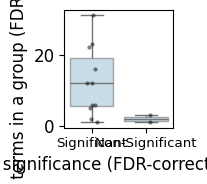

Fig7B -> Fig7B_fdr005.svg
  caption sentence for M9: (B) Mann–Whitney U, raw p = 0.113 (single test); n = 11 (Significant) vs 2 (Non-Significant).


In [18]:
go_count_box(enrichment_df_families, "Status", "GO_terms_count", "Fig7B",
             "Enrichment significance (FDR-corrected empirical p)",
             "GO terms in a group (FDR < 0.05)")

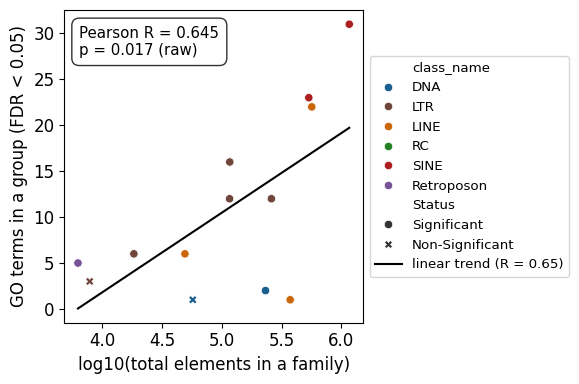

Fig7C: R = 0.645, p = 0.017 -> Fig7C_fdr005.svg


In [19]:
go_count_scatter(enrichment_df_families, "Total_TEs_number_log", "Fig7C",
                 "log10(total elements in a family)")

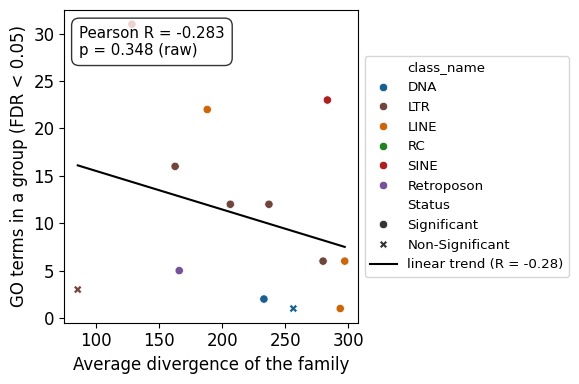

Fig7D: R = -0.283, p = 0.348 -> Fig7D_fdr005.svg


In [20]:
go_count_scatter(enrichment_df_families, "Average_divergence_all", "Fig7D",
                 "Average divergence of the family")

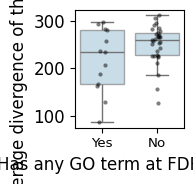

Fig7E -> Fig7E_fdr005.svg
  caption sentence for M9: (E) Mann–Whitney U, raw p = 0.208 (single test); n = 13 (Yes) vs 31 (No).


In [21]:
go_count_box(enrichment_df_families, "GO_status", "Average_divergence_all", "Fig7E",
             "Has any GO term at FDR < 0.05", "Average divergence of the family")

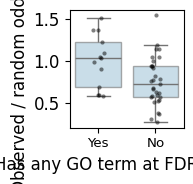

Fig7F -> Fig7F_fdr005.svg
  caption sentence for M9: (F) Mann–Whitney U, raw p = 0.029 (single test); n = 13 (Yes) vs 31 (No).


In [22]:
go_count_box(enrichment_df_families, "GO_status", "OR_Observed_to_Random", "Fig7F",
             "Has any GO term at FDR < 0.05", "Observed / random odds ratio")

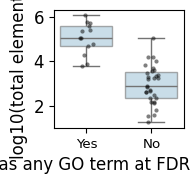

Fig7G -> Fig7G_fdr005.svg
  caption sentence for M9: (G) Mann–Whitney U, p < 0.001 (single test); n = 13 (Yes) vs 31 (No).


In [23]:
go_count_box(enrichment_df_families, "GO_status", "Total_TEs_number_log", "Fig7G",
             "Has any GO term at FDR < 0.05", "log10(total elements)")

### Figure 7H — the class ↔ functional group ↔ family Sankey

Copied from frozen cell 220 (the family-level Sankey), which is what the published caption
describes: *"Sankey plot visualization of GO term groups found in TE classes (left) and
families (right). Connecting ribbons were filtered by at least 5 GO terms. This filtering was
applied to the visualization only."* Ribbon heights use the log10 scale of the frozen cell;
the per-family Fisher stars test each family × functional-group cell against its own class,
BH-corrected, as in the frozen code.

**The filter was missing, and was added on 2026-08-05.** The first version applied the
threshold only to whether a ribbon's *count label* was printed — every ribbon was still
drawn. Filtering the ribbons themselves is what the caption describes, so this is a
conformance fix rather than a new request, and the caption also settles the design question
it raises: *"applied to the visualization only"* means bar heights and the underlying counts
stay at their full values, so retained ribbons do not fill their bars. That is correct and
already documented.

The unfiltered version is **Supplementary Figure S8C**, whose published caption already
describes it with no filter sentence: *"(C) Sankey plot of GO terms count comparison by
groups between the large-scale TE groups … and TE families."* Note `Figure S8C` (this
Sankey) is not `Figure 8C` (the IFNA subfamily composition panel) — every reference must
carry the `S`.

`plt.title(...)` is dropped (G11) and the y-axis wording now names FDR 0.05.

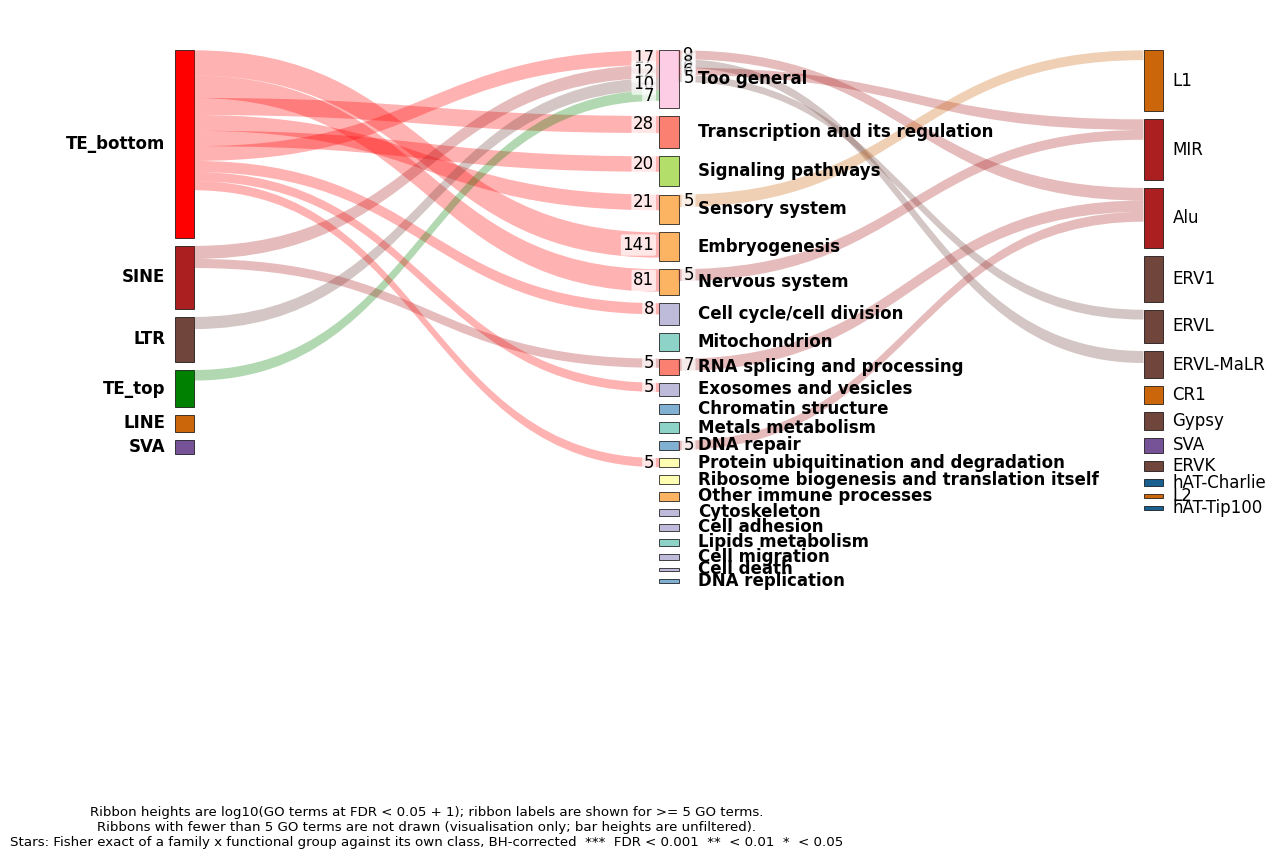

Fig7H -> Fig7H_fdr005.svg  (6 classes, 13 families, 22 functional groups); ribbons hidden: 36 class->group + 50 group->family, 146 GO terms


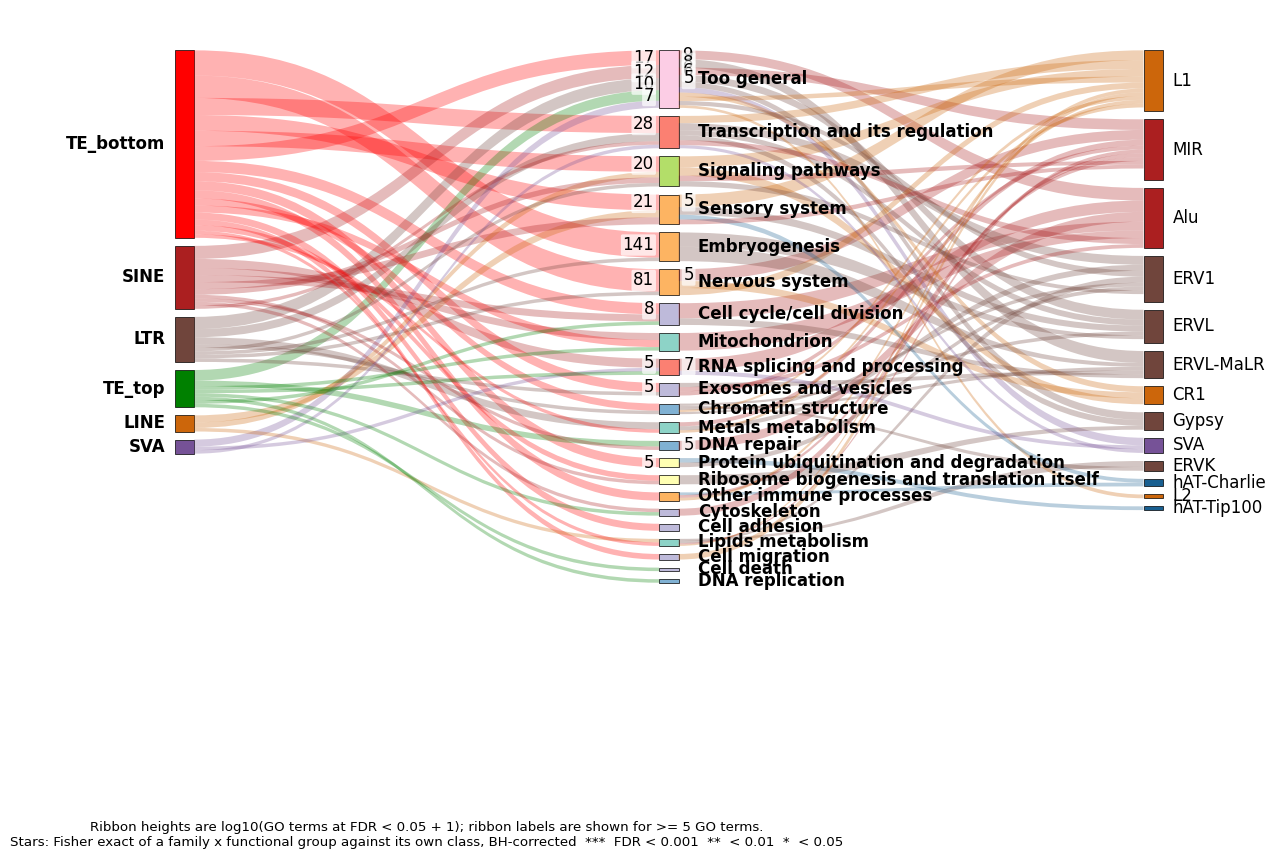

S8C_sankey_full -> S8C_sankey_full_fdr005.svg  (6 classes, 13 families, 22 functional groups); ribbons hidden: 0 class->group + 0 group->family, 0 GO terms



wrote sankey_ribbon_filter.json: {'Fig7H': {'min_ribbon_count': 5, 'class_to_group': 36, 'group_to_family': 50, 'terms_hidden': 146}, 'S8C_sankey_full': {'min_ribbon_count': 1, 'class_to_group': 0, 'group_to_family': 0, 'terms_hidden': 0}}


In [24]:
import matplotlib.patches as patches
from matplotlib.path import Path

# Functional metagroups and their palette, copied verbatim from frozen GO cell 3.
functional_metagroups = {
    "Metabolism": ["Carbohydrates metabolism", "Metals metabolism", "Lipids metabolism",
                   "Mitochondrion", "Xenobiotic metabolism", "Central metabolism",
                   "Aminoacids metabolism", "Sulfur metabolism", "Other metabolism"],
    "Proteins biogenesis": ["Protein ubiquitination and degradation",
                            "Ribosome biogenesis and translation itself",
                            "Protein folding"],
    "Cellular processes": ["Cell cycle/cell division", "Cell adhesion", "Cell migration",
                           "Cytoskeleton", "Cell death", "Exosomes and vesicles",
                           "Extracellular matrix"],
    "RNA biogenesis": ["Transcription and its regulation", "RNA splicing and processing"],
    "DNA biogenesis": ["Chromatin structure", "DNA repair", "DNA recombination",
                       "DNA replication"],
    "Organismal processes": ["Embryogenesis", "Nervous system", "Sensory system",
                             "Fertilization", "Other immune processes"],
    "Signaling pathways": ["Signaling pathways"],
    "other": ["Too general", "Other"],
}
metagroup_palette = {
    "Metabolism": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "Proteins biogenesis": (1.0, 1.0, 0.7019607843137254),
    "Cellular processes": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "RNA biogenesis": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "DNA biogenesis": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "Organismal processes": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "Signaling pathways": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "other": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
}
group_to_meta = {g: m for m, groups in functional_metagroups.items() for g in groups}

# The published caption's ">= 5 GO terms per ribbon" filter, applied to the ribbons
# themselves and to their labels. Figure 7H uses 5; Supplementary S8C uses 1, i.e. no
# filter. Because the filter is visual only, the bars keep their full heights.
RIBBON_LABEL_THRESHOLD = 5

# Ribbon endpoints come from the same FDR 0.05 tables the rest of the notebook uses.
counts_by_group_classes = (
    go_classes_count.merge(class_classification, how="left", on="Term Name")
    .dropna(subset=["Functional Group"])[["class_name", "Functional Group"]]
    .value_counts().reset_index(name="count"))
counts_by_group_families = (
    go_families.merge(family_classification, how="left", on="Term Name")
    .dropna(subset=["Functional Group"])[["class_name", "family_name", "Functional Group"]]
    .value_counts().reset_index(name="count"))
families_by_classes = dict(family_to_class)


def sankey_enrichment_testing(family_counts, class_counts, family_class_map):
    """Fisher enrichment of each family x functional-group cell against its own class.

    Frozen cell 220's construction, unchanged: the family's terms in that group against the
    family's other terms, versus the same split for the family's class.
    """
    class_group_totals = class_counts.set_index(
        ["class_name", "Functional Group"])["count"].to_dict()
    class_all_totals = class_counts.groupby("class_name")["count"].sum().to_dict()
    family_all_totals = family_counts.groupby("family_name")["count"].sum().to_dict()

    p_values = []
    for _, row in family_counts.iterrows():
        family, group, a = row["family_name"], row["Functional Group"], row["count"]
        class_name = family_class_map.get(family, "other")
        b = family_all_totals.get(family, a) - a
        class_group = class_group_totals.get((class_name, group), a)
        c = max(0, class_group - a)
        class_total = class_all_totals.get(class_name, a + b + c)
        d = max(0, (class_total - class_group) - b)
        p_values.append(fisher_exact([[a, b], [c, d]], alternative="greater")[1])

    family_counts = family_counts.copy()
    family_counts["p_adj"] = multipletests(p_values, method="fdr_bh")[1]
    family_counts["stars"] = family_counts["p_adj"].map(
        lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns")
    return family_counts


counts_by_group_families = sankey_enrichment_testing(
    counts_by_group_families, counts_by_group_classes, families_by_classes)
counts_by_group_classes["plot_count"] = np.log10(counts_by_group_classes["count"] + 1)
counts_by_group_families["plot_count"] = np.log10(counts_by_group_families["count"] + 1)


def bezier_ribbon(x1, y1_start, y1_end, x2, y2_start, y2_end):
    """Path for one curved Sankey ribbon between two vertical bars."""
    mid = x1 + (x2 - x1) / 2
    verts = [(x1, y1_start), (mid, y1_start), (mid, y2_start), (x2, y2_start),
             (x2, y2_end), (mid, y2_end), (mid, y1_end), (x1, y1_end), (x1, y1_start)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.LINETO,
             Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
    return Path(verts, codes)


def plot_sankey_classes_families(panel="Fig7H", min_ribbon_count=5):
    """One Sankey; ribbons carrying fewer than `min_ribbon_count` terms are not drawn."""
    dropped = {"class_to_group": 0, "group_to_family": 0, "terms_hidden": 0}
    fig, ax = plt.subplots(figsize=(15, 11))
    ax.set_xlim(-0.2, 2.2)
    ax.set_ylim(-1, 1.1)
    ax.axis("off")
    X_CLASS, X_GROUP, X_FAM, BAR_WIDTH, GAP_Y = 0, 1, 2, 0.04, 0.02
    font = rl.GLOBAL_FONT_SIZE

    total_val = counts_by_group_classes["plot_count"].sum()
    class_totals = (counts_by_group_classes.groupby("class_name")["plot_count"].sum()
                    .sort_values(ascending=False))
    class_pos, curr_y = {}, 1.0
    for name, val in class_totals.items():
        h = val / total_val * 0.9
        class_pos[name] = (curr_y - h, curr_y)
        ax.add_patch(patches.Rectangle((X_CLASS - BAR_WIDTH / 2, curr_y - h), BAR_WIDTH, h,
                                       facecolor=class_names_p.get(name, "gray"),
                                       ec="black", lw=0.5))
        ax.text(X_CLASS - 0.04, curr_y - h / 2, name, ha="right", va="center",
                fontsize=font, fontweight="bold")
        curr_y -= h + GAP_Y

    group_totals = (counts_by_group_classes.groupby("Functional Group")["plot_count"].sum()
                    .sort_values(ascending=False))
    group_pos, curr_y = {}, 1.0
    for name, val in group_totals.items():
        h = val / total_val * 0.9
        group_pos[name] = (curr_y - h, curr_y)
        ax.add_patch(patches.Rectangle(
            (X_GROUP - BAR_WIDTH / 2, curr_y - h), BAR_WIDTH, h,
            facecolor=metagroup_palette.get(group_to_meta.get(name, "other"), "gray"),
            ec="black", lw=0.5))
        ax.text(X_GROUP + 0.06, curr_y - h / 2, name, ha="left", va="center",
                fontsize=font, fontweight="bold")
        curr_y -= h + GAP_Y

    family_totals = (counts_by_group_families.groupby("family_name")["plot_count"].sum()
                     .sort_values(ascending=False))
    total_family_val = family_totals.sum()
    family_pos, curr_y = {}, 1.0
    for name, val in family_totals.items():
        h = val / total_family_val * 0.9
        family_pos[name] = (curr_y - h, curr_y)
        ax.add_patch(patches.Rectangle(
            (X_FAM - BAR_WIDTH / 2, curr_y - h), BAR_WIDTH, h,
            facecolor=class_names_p.get(families_by_classes.get(name, "other"), "gray"),
            ec="black", lw=0.5))
        ax.text(X_FAM + 0.04, curr_y - h / 2, name, ha="left", va="center", fontsize=font)
        curr_y -= h + GAP_Y

    class_offsets = {n: class_pos[n][1] for n in class_totals.index}
    group_offsets_left = {n: group_pos[n][1] for n in group_totals.index}
    for _, row in counts_by_group_classes.sort_values("plot_count",
                                                     ascending=False).iterrows():
        class_name, group, height = (row["class_name"], row["Functional Group"],
                                    row["plot_count"] / total_val * 0.9)
        if group not in group_pos:
            continue
        if row["count"] < min_ribbon_count:
            # Advance the offsets and draw nothing: the bars stay at their full height,
            # which is what "applied to the visualization only" means.
            dropped["class_to_group"] += 1
            dropped["terms_hidden"] += int(row["count"])
            class_offsets[class_name] -= height
            group_offsets_left[group] -= height
            continue
        ax.add_patch(patches.PathPatch(
            bezier_ribbon(X_CLASS + BAR_WIDTH / 2, class_offsets[class_name] - height,
                          class_offsets[class_name], X_GROUP - BAR_WIDTH / 2,
                          group_offsets_left[group] - height, group_offsets_left[group]),
            facecolor=class_names_p.get(class_name, "gray"), alpha=0.3, lw=0))
        if row["count"] >= RIBBON_LABEL_THRESHOLD:
            ax.text(X_GROUP - BAR_WIDTH / 2 - 0.01,
                    group_offsets_left[group] - height / 2, str(int(row["count"])),
                    ha="right", va="center", fontsize=font,
                    bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7,
                              edgecolor="none"))
        class_offsets[class_name] -= height
        group_offsets_left[group] -= height

    group_totals_family = counts_by_group_families.groupby("Functional Group")["plot_count"].sum()
    group_offsets_right = {n: group_pos[n][1] for n in group_pos}
    family_offsets = {n: family_pos[n][1] for n in family_totals.index}
    for _, row in counts_by_group_families.sort_values("plot_count",
                                                       ascending=False).iterrows():
        family, group = row["family_name"], row["Functional Group"]
        if group not in group_pos or family not in family_pos:
            continue
        visual_middle = group_pos[group][1] - group_pos[group][0]
        h_group = (row["plot_count"] / group_totals_family[group]) * visual_middle
        h_family = row["plot_count"] / total_family_val * 0.9
        class_name = families_by_classes.get(family, "other")
        if row["count"] < min_ribbon_count:
            dropped["group_to_family"] += 1
            dropped["terms_hidden"] += int(row["count"])
            group_offsets_right[group] -= h_group
            family_offsets[family] -= h_family
            continue
        ax.add_patch(patches.PathPatch(
            bezier_ribbon(X_GROUP + BAR_WIDTH / 2, group_offsets_right[group] - h_group,
                          group_offsets_right[group], X_FAM - BAR_WIDTH / 2,
                          family_offsets[family] - h_family, family_offsets[family]),
            facecolor=class_names_p.get(class_name, "gray"), alpha=0.3, lw=0))
        if row["count"] >= RIBBON_LABEL_THRESHOLD:
            ax.text(X_GROUP + BAR_WIDTH / 2 + 0.01,
                    group_offsets_right[group] - h_group / 2, str(int(row["count"])),
                    ha="left", va="center", fontsize=font,
                    bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7,
                              edgecolor="none"))
        if row["stars"] != "ns":
            ax.text(X_FAM - 0.05, family_offsets[family] - h_family / 2, row["stars"],
                    ha="right", va="center", color="black", fontsize=font,
                    fontweight="bold")
        group_offsets_right[group] -= h_group
        family_offsets[family] -= h_family

    filter_sentence = (
        f"Ribbons with fewer than {min_ribbon_count} GO terms are not drawn "
        f"(visualisation only; bar heights are unfiltered).\n"
        if min_ribbon_count > 1 else ""
    )
    ax.text(0.5, -0.98,
            "Ribbon heights are log10(GO terms at FDR < 0.05 + 1); ribbon labels are shown "
            "for >= 5 GO terms.\n" + filter_sentence
            + "Stars: Fisher exact of a family x functional group against "
            "its own class, BH-corrected  ***  FDR < 0.001  **  < 0.01  *  < 0.05",
            ha="center", va="bottom", fontsize=rl.fs(8))

    path = os.path.join(SVG, f"{panel}_fdr005.svg")
    fig.savefig(path, format="svg", transparent=True, bbox_inches="tight")
    plt.show()
    print(f"{panel} -> {os.path.basename(path)}  "
          f"({counts_by_group_classes['class_name'].nunique()} classes, "
          f"{counts_by_group_families['family_name'].nunique()} families, "
          f"{len(group_pos)} functional groups); "
          f"ribbons hidden: {dropped['class_to_group']} class->group + "
          f"{dropped['group_to_family']} group->family, "
          f"{dropped['terms_hidden']} GO terms")
    return dropped


# Figure 7H is the filtered panel the published caption describes; S8C is the same plot
# with every ribbon drawn, which is what its own caption describes.
sankey_filter_record = {
    "Fig7H": {"min_ribbon_count": 5,
              **plot_sankey_classes_families(panel="Fig7H", min_ribbon_count=5)},
    "S8C_sankey_full": {"min_ribbon_count": 1,
                        **plot_sankey_classes_families(panel="S8C_sankey_full",
                                                       min_ribbon_count=1)},
}
with open(os.path.join(OUT, "sankey_ribbon_filter.json"), "w") as handle:
    json.dump(sankey_filter_record, handle, indent=2)
print("\nwrote sankey_ribbon_filter.json:", sankey_filter_record)

### Figure 7 statistics, written out

Every number the revised Results paragraph quotes for Figure 7, so the text cannot drift
from the panels.

In [25]:
figure7_rows = []
for panel, column in [("7A", "OR_Observed_to_Random"),
                      ("7C", "Total_TEs_number_log"),
                      ("7D", "Average_divergence_all")]:
    frame = enrichment_df_families.dropna(subset=[column, "GO_terms_count"])
    result = stats.pearsonr(frame[column], frame["GO_terms_count"])
    figure7_rows.append({"panel": panel, "test": "Pearson r (raw)", "x": column,
                         "n": len(frame), "statistic": result.statistic,
                         "p_raw": result.pvalue})
for panel, split, value in [("7B", "Status", "GO_terms_count"),
                            ("7E", "GO_status", "Average_divergence_all"),
                            ("7F", "GO_status", "OR_Observed_to_Random"),
                            ("7G", "GO_status", "Total_TEs_number_log")]:
    frame = enrichment_df_families.dropna(subset=[value])
    order = [g for g in ["Significant", "Non-Significant", "Yes", "No"]
             if g in set(frame[split])]
    a = frame.loc[frame[split] == order[0], value]
    b = frame.loc[frame[split] == order[1], value]
    figure7_rows.append({"panel": panel, "test": "Mann-Whitney U (raw)", "x": split,
                         "n": f"{len(a)} vs {len(b)}",
                         "statistic": f"medians {a.median():.4g} vs {b.median():.4g}",
                         "p_raw": stats.mannwhitneyu(a, b).pvalue})
figure7_statistics = pd.DataFrame(figure7_rows)
figure7_statistics.to_csv(os.path.join(OUT, "figure7_statistics.csv"), index=False)
print(figure7_statistics.to_string(index=False))

# Panels 7B/7E/7F/7G lost their in-panel statistics to the half-size redesign, so the
# sentences that must appear in the Figure 7 legend (manuscript edit M9) are generated
# here rather than retyped.
print("\nFigure 7 legend sentences for M9:")
for panel in ["Fig7B", "Fig7E", "Fig7F", "Fig7G"]:
    print(f"  ({panel[-1]}) {figure7_caption_sentences.get(panel, 'MISSING')}")

panel                 test                      x        n              statistic    p_raw
   7A      Pearson r (raw)  OR_Observed_to_Random       13               0.167316 0.584821
   7C      Pearson r (raw)   Total_TEs_number_log       13                0.64548 0.017185
   7D      Pearson r (raw) Average_divergence_all       13              -0.283357 0.348171
   7B Mann-Whitney U (raw)                 Status  11 vs 2        medians 12 vs 2 0.112823
   7E Mann-Whitney U (raw)              GO_status 13 vs 31   medians 233.1 vs 260 0.207505
   7F Mann-Whitney U (raw)              GO_status 13 vs 31 medians 1.041 vs 0.725 0.028779
   7G Mann-Whitney U (raw)              GO_status 13 vs 31 medians 5.067 vs 2.892 0.000001

Figure 7 legend sentences for M9:
  (B) Mann–Whitney U, raw p = 0.113 (single test); n = 11 (Significant) vs 2 (Non-Significant).
  (E) Mann–Whitney U, raw p = 0.208 (single test); n = 13 (Yes) vs 31 (No).
  (F) Mann–Whitney U, raw p = 0.029 (single test); n = 13 (Yes) v

## 9. QC record and the list of SVGs

`network_qc.json` is the evidence for the "no overlapping text" claim: node counts and the
measured label-collision count per panel.

In [26]:
with open(os.path.join(OUT, "network_qc.json"), "w") as handle:
    json.dump(network_qc, handle, indent=2)

print("network / label QC — packing outcome per panel:")
for panel, record in sorted(network_qc.items()):
    print(f"  {panel:24s} area x{record.get('canvas_area_vs_baseline')}  "
          f"top_n={record.get('top_n')}  "
          f"collisions={record.get('label_collisions')}  "
          f"compaction target met={record.get('compaction_target_met')}")
    print(f"  {'':24s} rung: {record.get('fallback_rung')}")
    if record.get("best_compaction_attempt"):
        best = record["best_compaction_attempt"]
        print(f"  {'':24s} best compaction rung tried: {best['collisions']} "
              f"collision(s) at {best['rung']}")

print("\nSVGs written by this notebook:")
for name in sorted(os.listdir(SVG)):
    if any(name.startswith(p) for p in ("Fig4", "Fig5", "Fig6", "Fig7", "S8B", "S8C",
                                        "S9", "S10", "S11")):
        print(f"  {name:38s} {os.path.getsize(os.path.join(SVG, name)):>9,} B")

network / label QC — packing outcome per panel:
  Fig4A_simplified.svg     area x1.562  top_n=10  collisions=0  compaction target met=False
                           rung: full labels, x1.25 k=0.6 expand=1.15
                           best compaction rung tried: 1 collision(s) at short labels, x0.90 k=0.45 expand=1.02
  Fig5A_simplified.svg     area x2.25  top_n=10  collisions=0  compaction target met=False
                           rung: short labels, x1.50 k=0.6 expand=1.15
                           best compaction rung tried: 9 collision(s) at short labels, x0.90 k=0.45 expand=1.15
  Fig6A_simplified.svg     area x2.25  top_n=7  collisions=0  compaction target met=False
                           rung: short labels, x1.50 k=0.6 expand=1.15, top_n=7
                           best compaction rung tried: 13 collision(s) at short labels, x0.90 k=0.45 expand=1.02
  S10_full.svg             area x1.0  top_n=30  collisions=0  compaction target met=False
                           rung